# PRCP-1010 - Insurance Claim Prediction

## Objectives  

**Exploratory Data Analysis**  
Understand the dataset: shape, datatypes, ditribution, class imbalance, missing values etc. 

**Modelling and Interpretability**  
Build a predictive model which will help the insurance marketing team to know which customer will make the claim.

**Suggestions to the Insurance Marketing team**  
To make better business decsions.  

**Metrics**: Recall, Precision, F1-Score, ROC-AUC Score, PR-AUC Score  
**Dataset**: Insurance dataset  


## Import Libraries

In [1]:
# core libraries
import os
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, precision_recall_curve,confusion_matrix, average_precision_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# saving the model
import joblib

#feature importance
import shap

# warnings
import warnings
warnings.filterwarnings("ignore")

# pandas setup
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Read the Data

In [4]:
df = pd.read_csv(os.path.join("Data","train.csv"))

## Exploratory Data Analysis

In [ ]:
df.shape

(595212, 59)

In [ ]:
df.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,12,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11,1,-1,0,-1,14,1,1,2,1,82,3,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

In [ ]:
df.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,0.185304,0.000373,0.001692,0.009439,0.000948,0.012451,7.299922,0.660823,0.121081,0.153446,0.610991,0.439184,0.551102,8.295933,0.829931,-0.504899,0.725192,-0.157732,6.555340,0.910027,0.832080,1.328890,0.992136,62.215674,2.346072,0.379945,0.813265,0.276256,3.065899,0.449756,0.449589,0.449849,2.372081,1.885886,7.689445,3.005823,9.225904,2.339034,8.433590,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,0.388544,0.019309,0.041097,0.096693,0.030768,0.127545,3.546042,0.473430,0.326222,0.360417,0.287643,0.404264,0.793506,2.508270,0.375716,0.788654,2.153463,0.844417,5.501445,0.347106,0.373796,0.978747,0.091619,33.012455,0.832548,0.058327,0.224588,0.357154,0.731366,0.287198,0.286893,0.287153,1.117219,1.134927,1.334312,1.414564,1.459672,1.246949,2.904597,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,1.000000,-1.000000,-1.000000,0.250619,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.400000,0.200000,0.525000,7.000000,1.000000,-1.000000,0.000000,-1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,32.000000,2.000000,0.316228,0.670867,0.333167,2.828427,0.200000,0.200000,0.200000,2.000000,1.000000,7.000000,2.000000,8.000000,1.000000,6.000000,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.700000,0.300000,0.720677,7.000000,1.000000,-1.000000,0.000000,0.000000,7.0000

### Missing value analysis

In [ ]:
df.isnull().sum().sort_values(ascending = True).head()

id               0
ps_car_09_cat    0
ps_car_10_cat    0
ps_car_11_cat    0
ps_car_11        0
dtype: int64

**The data does not contain any missing values, so imputaion is not required.**

### Defining numerical and categorical columns based on cardinality
This data seems to have encoded categorical features int and float datatypes, So we cant seperate numerical and categorical columns based on dtypes. Therefore we filtered based on cardinality based on the assumption that categorical column have less cardinality than numerical ones. This step is important to apply scaling, as scaling is only done on continous numerical values.

In [9]:
cat_cols = []
num_cols = []

for col in df.columns:
    if df[col].nunique() < 20:
        cat_cols.append(col)
    else:
        num_cols.append(col)

In [10]:
print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 9
Categorical columns: 50


**It is important to identify numerical columns because we apply scaling only for numerical columns while building pipeline for baseline models(logistic regression and its variations)**

### Distribution Analysis
To decide what kind of scaling method to be used

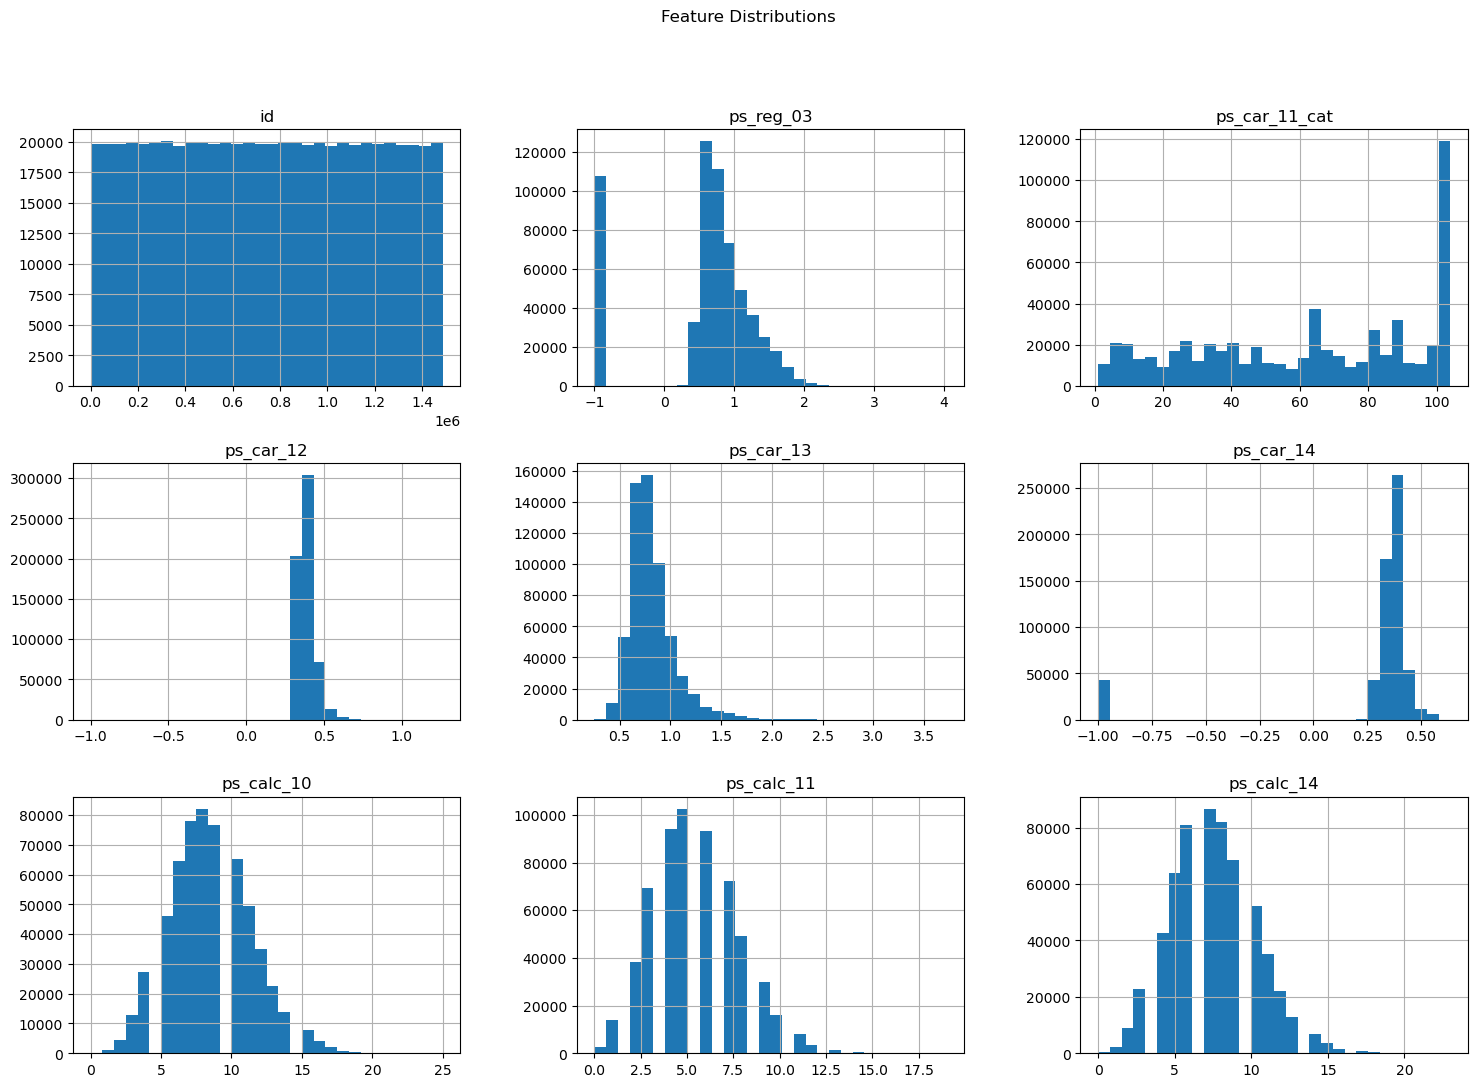

In [ ]:
df[num_cols].hist(figsize=(18,12), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

**Most nummerical features are heavily skewed and contains outliers, therefore RobestScaler is preferred scaling technique as it is unaffected by outliers.**

### Target Variable Analysis

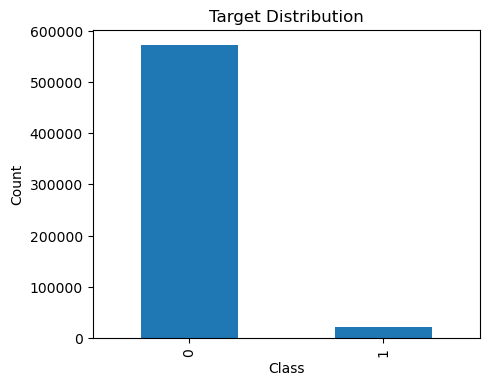

In [ ]:
plt.figure(figsize=(5,4))
df['target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

target
0    573518
1     21694
Name: count, dtype: int64
target
0    96.355248
1     3.644752
Name: proportion, dtype: float64


**We have severely imbalanced class distribution. Therefore we have to use class imbalance handling techniques like SMOTE, class weights according to the nature of the models**

## Features and Target

In [5]:
X = df.drop(['target'], axis=1) # features
y = df['target'] # Target
print(X.shape)
print(y.shape)

(595212, 58)
(595212,)


## Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% test set
    stratify=y,             # keeps class ratio
    random_state=42
)

#### Dimensions after train test split

In [7]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(476169, 58)
(119043, 58)
(476169,)
(119043,)


## Building Pipeline for Baseline Models (Logistic Regression)

In [13]:
num_cols.remove('id') # removing id column name from a list numerical column names as the id column gets deleted later in the preprocessing step
cat_cols.remove('target') # removing target column name from list of column names as they are not part of the features

#### Configuring Preprocessing steps

In [ ]:
preprocessor_1 = ColumnTransformer(
    transformers=[
        ("drop_id", "drop", ['id']),
        ("num_scale", RobustScaler(), num_cols),
        ("cat_pass", "passthrough", cat_cols)
    ]
)

**We drop ID column because it does not contain predictive information.  
Since, we are using Logistic regression and its variations as baseline models, scaling is vital. Therefore, Robestscaler is employed and they are also good with skewed distributions.  
Categorical columns are already encoded so no changes are made for them.**

#### Baseline models requiring scaling and SMOTE

In [ ]:
models_1 = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Lasso": LogisticRegression(penalty='l1', solver='liblinear', max_iter=5000),
    "Ridge": LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000),
}

#### Function for model evaluation

In [3]:
results = []

def evaluate(model_name, y_test, y_pred, y_prob):

    print(f"\n===== {model_name} =====")

    auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print("ROC-AUC:", round(auc, 4))
    print("PR-AUC:", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


### Model Training and Evaluation

In [ ]:
fitted_models = {}

for name, model in models_1.items():

    print(f"Training {name}...")

    # PIPELINE
    pipe = ImbPipeline([
        ("preprocess", preprocessor_1),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    fitted_models[name] = model

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    evaluate(name, y_test, y_pred, y_prob)

Training Logistic Regression...

===== Logistic Regression =====
ROC-AUC: 0.6131
PR-AUC: 0.0572

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74    114704
           1       0.05      0.56      0.09      4339

    accuracy                           0.59    119043
   macro avg       0.51      0.58      0.41    119043
weighted avg       0.94      0.59      0.71    119043

Training Lasso...

===== Lasso =====
ROC-AUC: 0.613
PR-AUC: 0.0572

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74    114704
           1       0.05      0.56      0.09      4339

    accuracy                           0.59    119043
   macro avg       0.51      0.58      0.41    119043
weighted avg       0.94      0.59      0.71    119043

Training Ridge...

===== Ridge =====
ROC-AUC: 0.6131
PR-AUC: 0.0572

Classification Report:
              precision    recall  f1-score

## Building Pipeline for Tree Models

In [10]:
preprocessor_2 = ColumnTransformer(
    transformers=[
        ("drop_id", "drop", ['id'])
    ],
    remainder="passthrough"
)

**Here scaling is not done because tree-baesed ensemble models does not need scaling.  
ID column is dropped here too as it does not have predictive information.  
categorical column are already encoded and handled the same way as before.**

#### Compute class imbalance ratio for XGBoost and LightGBM

In [39]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

#### Tree Models

In [41]:
models_2 = {
    "Random Forest": RandomForestClassifier(class_weight='balanced_subsample'),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_pos_weight)
}

### Model Training and Evaluation

In [ ]:
fitted_models = {}

for name, model in models_2.items():

    print(f"Training {name}...")

    #PIPELINE
    pipe = Pipeline([
        ("preprocess", preprocessor_2),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    fitted_models[name] = model

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    evaluate(name, y_test, y_pred, y_prob)

Training Random Forest...

===== Random Forest =====
ROC-AUC: 0.5765
PR-AUC: 0.0492

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114704
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119043
   macro avg       0.48      0.50      0.49    119043
weighted avg       0.93      0.96      0.95    119043

Training XGBoost...

===== XGBoost =====
ROC-AUC: 0.604
PR-AUC: 0.0589

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83    114704
           1       0.05      0.43      0.10      4339

    accuracy                           0.71    119043
   macro avg       0.51      0.57      0.46    119043
weighted avg       0.94      0.71      0.80    119043

Training LightGBM...
[LightGBM] [Info] Number of positive: 17355, number of negative: 458814
[LightGBM] [Info] Auto-choosing row-wise multi-thr

**Out of all the model trained the lightGBM model has the highest PR-AUC Score. Therefore, LightGBM model has been selected for further improvements.**

### Hyperparameter Tuning of lightGBM model

In [13]:
base_lgb = LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
lgb_pipe = Pipeline([
        ("preprocess", preprocessor_2),
        ("model", base_lgb)
    ])

In [17]:
# defining parameters to tune
param_grid = {
    "model__num_leaves": [31, 63, 127],
    "model__learning_rate": [0.01, 0.05],
    "model__min_child_samples": [20, 50, 100],
    "model__subsample": [0.7, 0.9],
    "model__colsample_bytree": [0.7, 0.9],
    "model__n_estimators": [300, 500, 800]
}

In [18]:
lgb_random = RandomizedSearchCV(
    estimator=lgb_pipe,
    param_distributions=param_grid,
    n_iter=5,                 
    scoring='roc_auc',          
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [19]:
lgb_random.fit(X_train, y_train)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[LightGBM] [Info] Number of positive: 17355, number of negative: 458814
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.137416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1367
[LightGBM] [Info] Number of data points in the train set: 476169, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036447 -> initscore=-3.274764
[LightGBM] [Info] Start training from score -3.274764


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('drop_id',
                                                                               'drop',
                                                                               ['id'])])),
                                             ('model',
                                              LGBMClassifier(n_estimators=500,
                                                             n_jobs=-1,
                                                             objective='binary',
                                                             random_state=42,
                                                             scale_pos_weight=np.float64(26.436992221261885)))]),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.9],
                                        'model__learning_rate': [0.01, 0.05],
                                        'model__min_child_samples': [20, 50,
                                                                     100],
                                        'model__n_estimators': [300, 500, 800],
                                        'model__num_leaves': [31, 63, 127],
                                        'model__subsample': [0.7, 0.9]},
                   random_state=42, scoring='roc_auc', verbose=2)

#### Best parameters

In [32]:
print("Best Params:", lgb_random.best_params_)

Best Params: {'model__subsample': 0.7, 'model__num_leaves': 31, 'model__n_estimators': 800, 'model__min_child_samples': 50, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}


### Saving the progress (RandomizedSearchCV object)

In [25]:
joblib.dump(lgb_random, "best_lgbm_pipeline.pkl")

['best_lgbm_pipeline.pkl']

### Loading the RandomizedCV object

In [8]:
lgb_random = joblib.load("best_lgbm_pipeline.pkl") # RandomizedSearchCV object

In [9]:
best_model = lgb_random.best_estimator_ # sklearn Pipeline object

In [10]:
y_pred = lgb_random.predict(X_test) # prediction using best model
y_prob = lgb_random.predict_proba(X_test)[:, 1]

In [11]:
evaluate('lgb_random', y_test, y_pred, y_prob)


===== lgb_random =====
ROC-AUC: 0.6396
PR-AUC: 0.0676

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.64      0.77    114704
           1       0.06      0.56      0.10      4339

    accuracy                           0.64    119043
   macro avg       0.52      0.60      0.44    119043
weighted avg       0.94      0.64      0.75    119043



## Thresold Tuning

In [15]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

### Precision, Recall, F1-Score for different thresolds

In [16]:
thresholds = np.arange(0.01, 1.00, 0.01)

precision_scores = []
recall_scores = []
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision_scores.append(precision_score(y_test, y_pred_t))
    recall_scores.append(recall_score(y_test, y_pred_t))
    f1_scores.append(f1_score(y_test, y_pred_t))

### Plotting the Scores vs Threshold

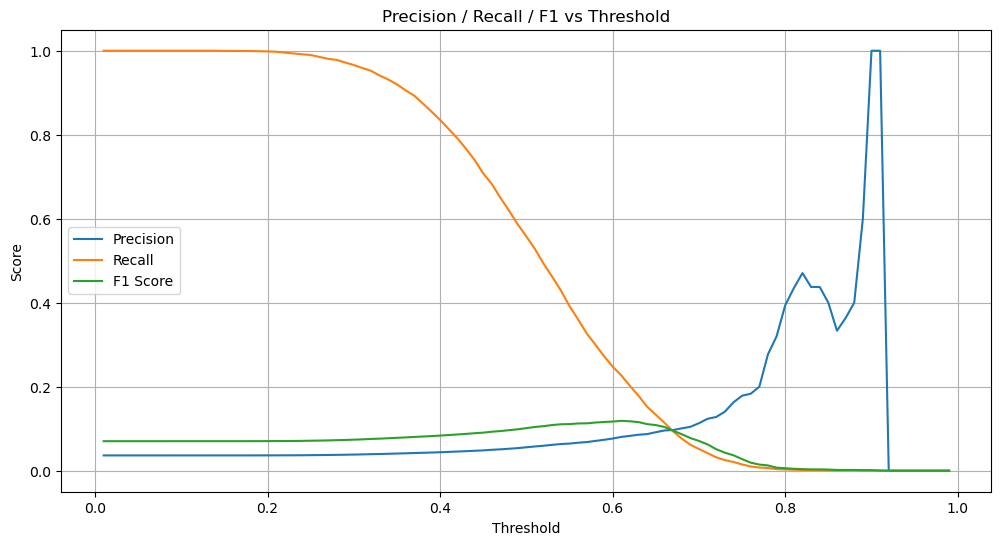

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(thresholds, precision_scores, label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.title('Precision / Recall / F1 vs Threshold')
plt.show()

**The peak f1-score is seen around threshold value 0.6. But our goal here is to catch as many claimers as possible, so we have to choose a lower thresold.**

In [29]:
# Get precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

In [30]:
#applying business constraint
# Suppose we want recall >= 0.9 (catch at least 90% of insurance claimers)
idx = np.where(recall >= 0.9)[0]  # indices satisfying recall constraint

# Choose threshold that maximizes precision under this constraint
best_idx = idx[np.argmax(precision[idx])]
best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)

Best threshold: 0.3634192902376798


In [31]:
# Apply threshold to make predictions
y_pred_tuned = (y_prob >= best_threshold).astype(int)

# Evaluate
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

[[24759 89945]
 [  429  3910]]
              precision    recall  f1-score   support

           0       0.98      0.22      0.35    114704
           1       0.04      0.90      0.08      4339

    accuracy                           0.24    119043
   macro avg       0.51      0.56      0.22    119043
weighted avg       0.95      0.24      0.34    119043



## Interpretation with SHAP

(10000, 57)


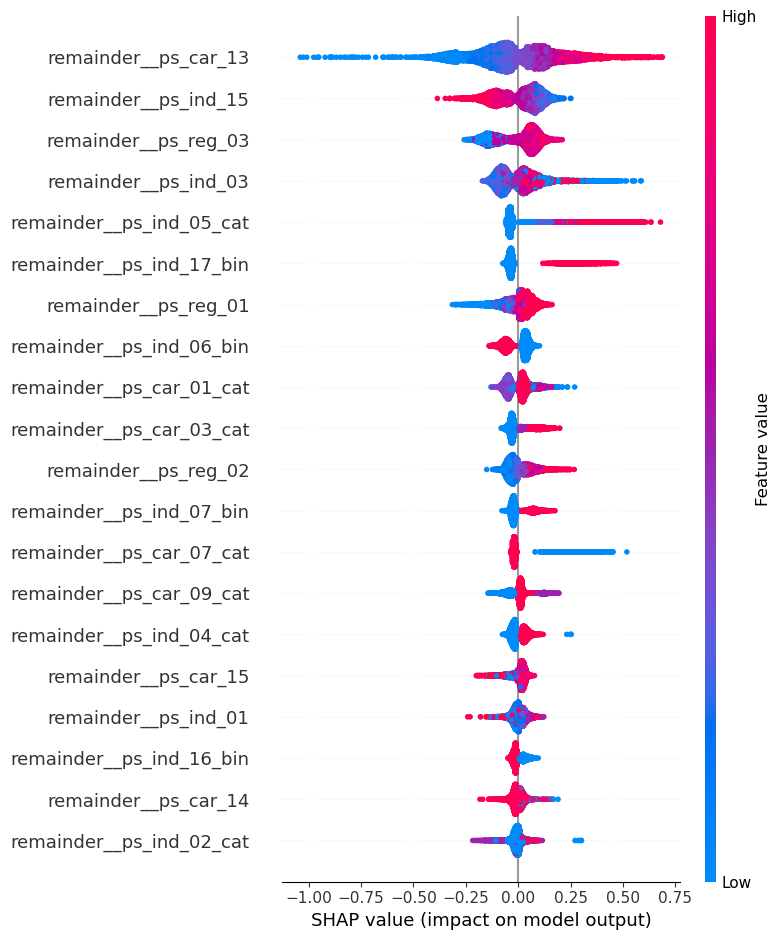

In [23]:
best_model_lgm = best_model.named_steps["model"] # extracting only the model part from the pipeline
preprocessor = best_model.named_steps["preprocess"] # extracting the preprocessor part
X_test_transformed = preprocessor.transform(X_test) # transforming testing data as SHAP needs model-ready input
feature_names = preprocessor.get_feature_names_out() # extracting feature names
shap_sample = X_test_transformed[:10000] # taking a subset of sample for speed
explainer = shap.TreeExplainer(best_model_lgm) # create SHAP explainer for LightGBM
shap_values = explainer.shap_values(shap_sample)# Get the shap values
# Handle binary-class cases
if isinstance(shap_values, list):
    shap_values = shap_values[1]   # positive class
# shap_values must be (n_samples, n_features)
print(shap_values.shape)
shap.summary_plot(shap_values, shap_sample, feature_names = feature_names) # SHAP Summary beeswarm plot


The above **SHAP Beeswarm plot** shows how each feature influences model predictions.  

**X-axis -- SHAP value**  
Positice SHAP value -> pushes prediciton towards the postive class(insurance claimers)
Negative SHAP value -> pushes prediction towards the negative class  
**Y-axis -- Features(sorted by importance)**  
Higher up -> more important feature
importance = mean absolute SHAP value  
**Colors Meaning**
Red -> higher feature value  
Blue -> low feature value  
Example:  
Red points on right side -> high values increase positive prediction  
Blue points on left -> low values decrease prediction  
**Density**  
Many points at similar SHAP value -> consistent model beaviour.  
Wide spread -> model reacts differently across different samples.  

### Insights from SHAP plot

**1. ps_car_13 is the most influential feature**  
It shows the widest spread of SHAP values (around −1.0 to +0.7).  
This means ps_car_13 has the strongest effect on prediction—both increasing and decreasing the probability depending on its value.    
Red points (high values) mostly lie on the right (positive SHAP).  
Blue points (low values) lie more on the left (negative SHAP).  
High ps_car_13 pushes the model toward predicting “1”, and low values push toward “0”. 

**2. ps_ind_15 influences the prediction, but the effect varies across samples.**  
SHAP distribution suggests interaction effects rather than a simple direct relationship.  
High values sometimes increase prediction    
High values sometimes decrease prediction    
Low values also behave inconsistently  
The model is using this feature in combination with other features, not independently  

**3. Some binary/categorical features act asymmetrically**   
Example: ps_ind_17_bin, ps_ind_06_bin, ps_ind_07_bin  
They show clusters of red or blue points entirely on one side.  
This means certain categories always push the prediction in one direction, and the model treats those categories as strong signals.  

**4. ps_reg_03 and ps_ind_03 have mixed behavior**  
Both red and blue points appear on both left and right. 
Their influence on prediction depends on the sample rather than a simple monotonic relationship.  
These features interact with others (interaction effects).  

### Suggestions to the Insurance market team


1. Offer discounted premiums or promotional offers to customers with low **ps_car_13** values.  
These customers are statistically less likely to claim → more profitable segment.
2. Customers with lower **ps_reg_03** values are safer
Push policy offers to customers with lower ps_reg_03 values.  
These are stable, low-risk profiles.  
3. Binary features like **ps_ind_06_bin** and **ps_ind_07_bin** strongly separate high vs low risk.
Create targeted micro-campaigns for safe categories.
4. Use the model for premium adjustment & product differentiation  
For high-risk customers (right side of SHAP):  
-->Increase premiums  
-->Provide risk-reduction training programs   
For low-risk customers (left side of SHAP):  
-->Offer attractive low-premium plans  
-->Target them for maximum profitability  


### Challenges faced

**1. Huge dataset**  
Took long time to train the models.  

**2. Dataset with no domain related feature names.**  
Random feature names were given due to privacy concerns.  
Therefore, it was difficult to interpret data.  
Therefore meaningful feature creation from existing feautures were not possible.  
Not sure which of the columns are numerical and categorical.
Tried to distinguish numerical from categorical using cardinality. (not sure how accurate it is)  

**3. Numericial Columns are out of scale and skewed**  
Hence, scaled using RobestScaler   

**4. Severe Class Imbalance**  
The monirity class(insurance claimers) were only less than 4%.  
Choosing the right class imbalce habdling technique was tricky.  
Class imbalance handling techniques like SMOTE and class weights were employed according to the nature of the models.

**5. Deciding the correct evaluation metric**   
Accuracy was misleading due to imbalance. Choosing AUC-ROC, precision-recall, and threshold optimization was crucial.

**6. Hyperparameter Tuning was too slow**  
LightGBM model took significant time for hyperparameter tuning due to High dimensionality.  
Therefore hyperparameter tuning was done using RandomizedSearchCV with very few combinations of hyperparemeters and a cv of 2. (Got only minor improvements in model performance).   

**7. Threshold Tuning**  
Some assumptions were made like prioritizing recall of claimers's class. before threshold tuning as we are not aware about the company requirements.   
Threshold tuning becomes a full optimzation problem the moment we introduce business values like profit, cost and risk. 

**8. Interpretability of a black-box model(LightGBM)**  
SHAP(SHapley Additive exPlanations) was implemented for interpreting the feature importance, which in turn can help us make better business decisions.  




### Future Work

More extensive hyperparameter tuning could be done on all type of model.  
New featrues can be created form existing features.  
Threshold tuning could be done in a more informed manner considering business values.  
Outlier handling techniques like Winsorization could be used for linear models  
Deep learning models could be used for better performance.